In [54]:
import numpy as np
import pandas as pd
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import random
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import statsmodels.formula.api as smf
import copy

In [76]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """    pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor


def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (X, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지. 한 배치를 시작할 때 이전 배치의 gradient를 먼저 지우고, 현재 배치의 gradient만 계산
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()         # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()        # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)       # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적


    return total_loss / len(dataloader.dataset)     # 전체 데이터 개수로 나누어 epoch 평균 loss 반환



def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()         # 모델을 평가 모드로 설정

    with torch.no_grad():       # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred


def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# =================================== MultiTask 용========================================
def make_multitask_dataset(
    x_train,
    x_val,
    y_reg_train,
    y_reg_val,
    y_cls_train,
    y_cls_val,
    batch_size=32
):
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)

    y_reg_train_tensor = torch.tensor(y_reg_train.values, dtype=torch.float32).view(-1, 1)
    y_reg_val_tensor = torch.tensor(y_reg_val.values, dtype=torch.float32).view(-1, 1)

    y_cls_train_tensor = torch.tensor(y_cls_train.values, dtype=torch.long)
    y_cls_val_tensor = torch.tensor(y_cls_val.values, dtype=torch.long)

    train_dataset = TensorDataset(
        x_train_tensor,
        y_reg_train_tensor,
        y_cls_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return train_loader, x_val_tensor, y_reg_val_tensor, y_cls_val_tensor

def train_multitask(
    dataloader,
    model,
    reg_loss_fn,
    cls_loss_fn,
    optimizer,
    device,
    alpha=1.0,
    beta=0.3
):
    model.train()
    total_loss = 0

    for x, y_reg, y_cls in dataloader:
        x = x.to(device)
        y_reg = y_reg.to(device)
        y_cls = y_cls.to(device)

        optimizer.zero_grad()

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate_multitask(
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    model,
    reg_loss_fn,
    cls_loss_fn,
    device,
    alpha=1.0,
    beta=0.3
):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_reg = y_reg_val_tensor.to(device)
        y_cls = y_cls_val_tensor.to(device)

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

    return loss.item(), reg_pred, cls_pred

def evaluate_multitask_metrics(
    model,
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    device
):
    model.eval()

    with torch.no_grad():
        reg_pred, cls_pred = model(x_val_tensor.to(device))

    y_reg_pred = reg_pred.cpu().numpy().flatten()
    y_reg_true = y_reg_val_tensor.cpu().numpy().flatten()

    y_cls_pred = torch.argmax(cls_pred, dim=1).cpu().numpy()
    y_cls_true = y_cls_val_tensor.cpu().numpy()

    mse = mean_squared_error(y_reg_true, y_reg_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg_true, y_reg_pred)
    r2 = r2_score(y_reg_true, y_reg_pred)

    acc = accuracy_score(y_cls_true, y_cls_pred)

    print("Regression")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    print("\nClassification")
    print("Accuracy:", acc)
    print(confusion_matrix(y_cls_true, y_cls_pred))
    print(classification_report(y_cls_true, y_cls_pred))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "accuracy": acc,
        "y_reg_true": y_reg_true,
        "y_reg_pred": y_reg_pred,
        "y_cls_true": y_cls_true,
        "y_cls_pred": y_cls_pred,
    }

def parse_json_list(value):
    """JSON 문자열(list[dict])을 파이썬 list로 변환."""
    if pd.isna(value) or value == "":
        return []

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except json.JSONDecodeError:
        return []


def parse_json_dict(value):
    """JSON 문자열(dict)을 파이썬 dict로 변환."""
    if pd.isna(value) or value == "":
        return {}

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}
    
class MultiTaskMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.reg_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

        self.cls_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        shared_out = self.shared(x)
        return self.reg_head(shared_out), self.cls_head(shared_out)

def save_regression_model(model, preprocessor, feature_cols, path="ml/models/regression_mlp_v3.pth"):
    save_dict = {
        "model_state_dict": model.state_dict(),
        "input_dim": len(feature_cols),
        "feature_cols": feature_cols,
        "standard_train": standard_train,
        "one_hot_train": one_hot_train,
        "no_encode_scale_train": no_encode_scale_train,
        "preprocessor": preprocessor,
    }

    torch.save(save_dict, path)
    print(f"saved: {path}")

### 피처 가공 및 데이터 불러오기

In [72]:
df = pd.read_csv('data/processed/feature_table_v3.csv')

In [47]:
tar_cols = ['total_audience', 'total_sales', 'log_audience']
exclude_cols = ['movie_id', 'title', 'genre', 'nation', 'open_date', 
 # v2 스펙 삭제 대상 피처 (다중공선성 방지)
    'open_month', 'director_movie_count', 'lead_actor_movie_count', 
    'distributor_movie_count', 'producer_movie_count','trend_pre30_avg', 'trend_pre7_avg',
    'is_summer', 'is_winter', 'total_sales']

dff = df.drop(columns = exclude_cols)
dff.columns

Index(['runtime', 'total_audience', 'director_avg_audi', 'lead_actor_avg_audi',
       'distributor_avg_audi', 'producer_avg_audi', 'trend_pre7_max',
       'trend_growth_rate', 'relative_search_share', 'market_avg_audi_7d',
       'ticket_price_pre30', 'open_day_of_week', 'is_peak_season',
       'is_covid_period', 'is_korean', 'holiday_nearby_count',
       'is_holiday_release', 'same_week_releases', 'is_new_director',
       'is_new_lead', 'is_new_producer', 'is_new_distributor', 'log_audience',
       'genre_avg_audi', 'rating_15세관람가', 'rating_15세이상관람가', 'rating_전체관람가',
       'rating_청소년관람불가'],
      dtype='str')

In [ ]:
left =['runtime', 'total_audience', 'director_avg_audi',
       'lead_actor_avg_audi', 'distributor_avg_audi', 'producer_avg_audi',
       'trend_pre7_max', 'trend_growth_rate', 'relative_search_share',
       'market_avg_audi_7d', 'ticket_price_pre30', 'open_day_of_week',
       'is_peak_season', 'is_covid_period', 'is_korean',
       'holiday_nearby_count', 'is_holiday_release', 'same_week_releases',
       'is_new_director', 'is_new_lead', 'is_new_producer',
       'is_new_distributor', 'log_audience', 'genre_avg_audi', 'rating_15세관람가',
       'rating_15세이상관람가', 'rating_전체관람가', 'rating_청소년관람불가']
       
standard = ['runtime', 'trend_pre7_max', 'trend_growth_rate', 'ticket_price_pre30',
            'holiday_nearby_count','same_week_releases']
one_hot = ['open_day_of_week', ]
no_encode_scale_cols = [ 'distributor_avg_audi',  'producer_avg_audi',
                  'lead_actor_avg_audi', 'director_avg_audi','is_peak_season',
                  'is_holiday_release','genre_avg_audi', 'is_korean', 'is_covid_period',
                  'is_new_director', 'is_new_lead', 'is_new_producer',
                  'is_new_distributor', 'market_avg_audi_7d', 'rating_15세관람가',
                  'rating_15세이상관람가'
                    , 'rating_전체관람가', 'rating_청소년관람불가', 'relative_search_share']
t_cols = ['total_audience', 'log_audience']


## 학습 제외할 컬럼 여기에 넣기
drop_when_train = ['trend_growth_rate', 'holiday_nearby_count' ]
ll = [c for c in left if c not in no_encode_scale_cols]
ll

['runtime',
 'total_audience',
 'trend_pre7_max',
 'trend_growth_rate',
 'ticket_price_pre30',
 'open_day_of_week',
 'holiday_nearby_count',
 'same_week_releases',
 'log_audience']

In [51]:
group = one_hot + standard + no_encode_scale_cols + t_cols
len(left) == len(group)

True

In [37]:
dff['holiday_nearby_count'].max()

np.int64(5)

In [4]:
o = [ 'runtime', 'rating_encoded', 'is_korean', 'genre', 'genre_avg_audi',
       'open_day_of_week']
t = [ 'is_holiday_release', 'holiday_nearby_count']
th = ['director_avg_audi',
       'director_movie_count', 'lead_actor_avg_audi', 'lead_actor_movie_count',
       'cast_max_star_power', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count']
f = [ 'same_week_releases']
fi = [ 'market_avg_audi_7d','trend_pre7_max',
       'trend_growth_rate', 'relative_search_share']
s = ['is_covid_period',
       'is_peak_season', 'ticket_price_pre30']
se = ['is_new_director', 'is_new_lead', 'is_new_producer',
       'is_new_distributor']

In [5]:
df[['log_audience']+se].corr(numeric_only=True)

,log_audience,is_new_director,is_new_lead,is_new_producer,is_new_distributor
log_audience,1.000000,-0.313931,-0.294841,-0.290251,0.260855
is_new_director,-0.313931,1.000000,0.176634,0.170356,-0.094306
is_new_lead,-0.294841,0.176634,1.000000,0.181940,-0.091008
is_new_producer,-0.290251,0.170356,0.181940,1.000000,-0.441062
is_new_distributor,0.260855,-0.094306,-0.091008,-0.441062,1.000000


c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\playdata\Desktop\workspace\SKN2nd\SKN30-2nd-4Team\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from

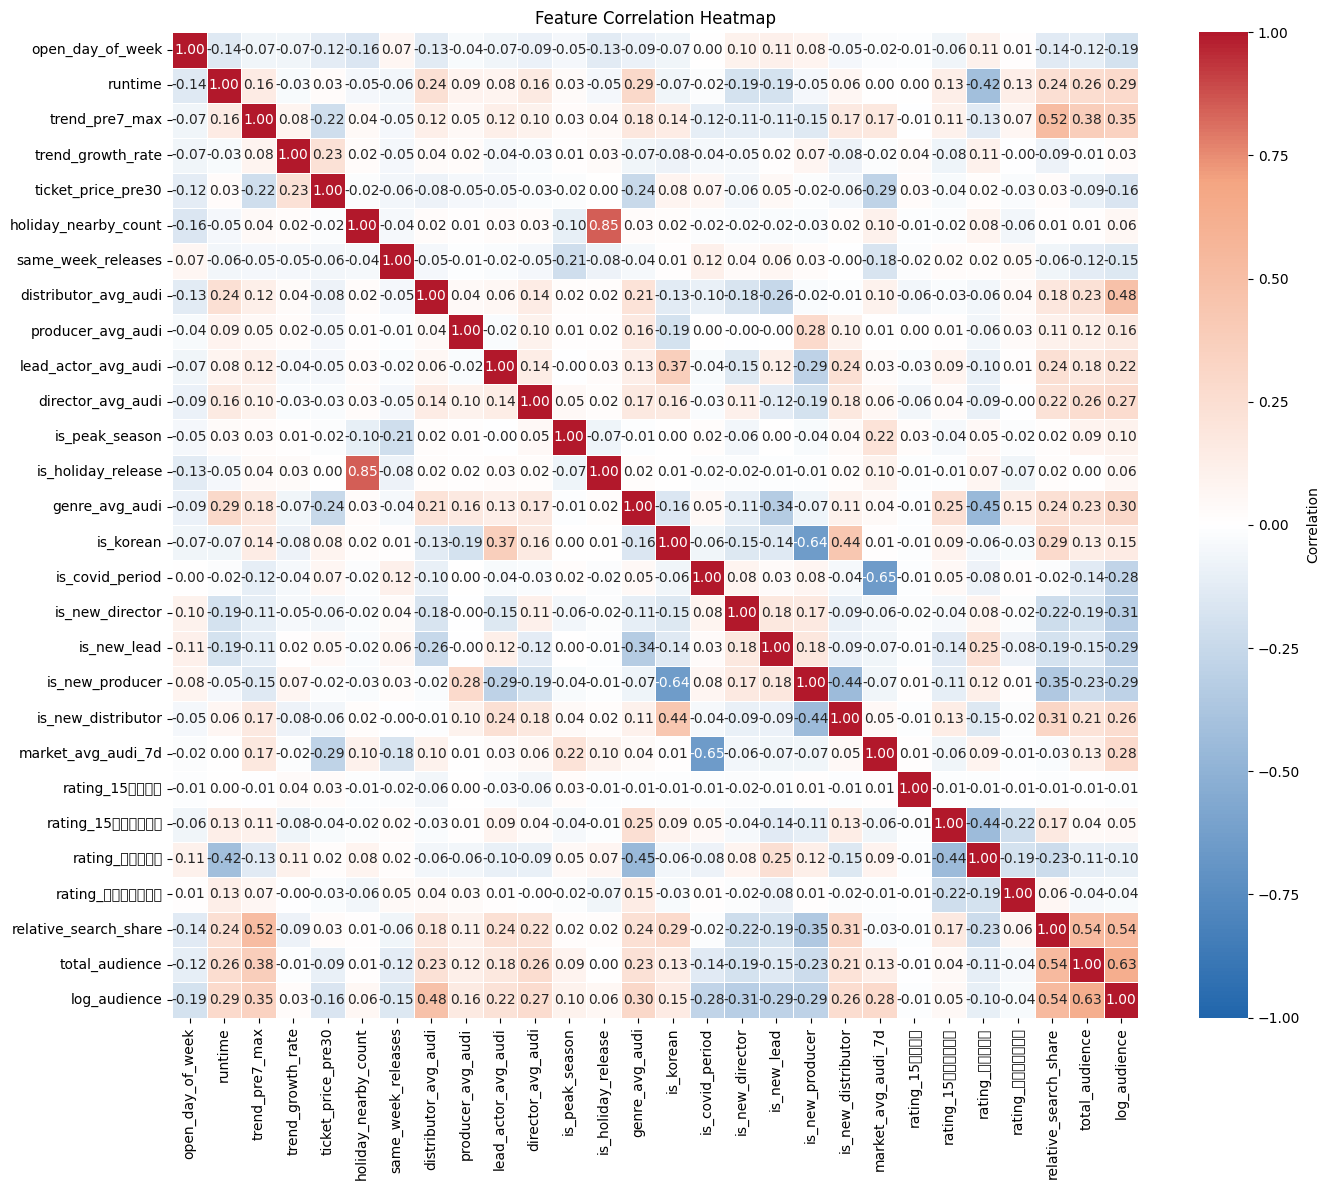

In [59]:
cmap = LinearSegmentedColormap.from_list(
    "corr_cmap",
    [
        (0.00, "#2166ac"),
        (0.50, "#ffffff"),
        (0.85, "#f4a582"),
        (1.00, "#b2182b"),
    ]
)

plt.figure(figsize=(14, 12))

corr = df[group].corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

학습 진행

Epoch 010 | train_loss: 4.1076 | val_loss: 2.1907
Epoch 020 | train_loss: 3.3244 | val_loss: 2.0217
Epoch 030 | train_loss: 3.1156 | val_loss: 1.8747
Epoch 040 | train_loss: 2.8818 | val_loss: 1.9551
Epoch 050 | train_loss: 2.8467 | val_loss: 1.7208
Epoch 060 | train_loss: 2.7611 | val_loss: 1.9190
Epoch 070 | train_loss: 2.6105 | val_loss: 1.7993
Epoch 080 | train_loss: 2.6142 | val_loss: 1.7150
Epoch 090 | train_loss: 2.4818 | val_loss: 1.9793
Epoch 100 | train_loss: 2.3843 | val_loss: 1.7509


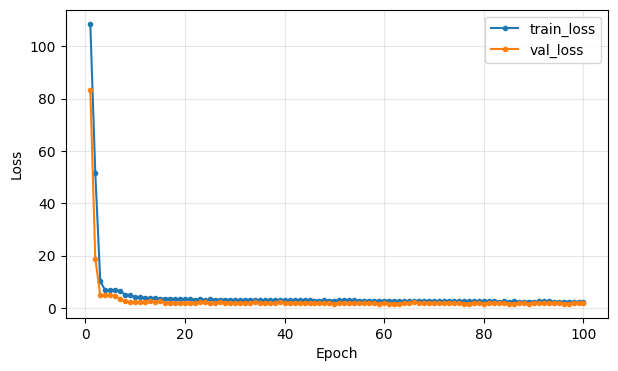

Regression
MSE : 1.7509160041809082
RMSE: 1.3232218272764806
MAE : 1.025783896446228
R2  : 0.6364225149154663


In [75]:
# 회귀 DL 학습 셀

target_col = "log_audience"

feature_cols_temp = standard + one_hot + no_encode_scale_cols

standard_train = [col for col in standard if col not in drop_when_train]
one_hot_train = [col for col in one_hot if col not in drop_when_train]
no_encode_scale_train = [col for col in no_encode_scale_cols if col not in drop_when_train]

feature_cols = standard_train + one_hot_train + no_encode_scale_train

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("standard", StandardScaler(), standard_train),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_train),
        ("passthrough", "passthrough", no_encode_scale_train),
    ],
    remainder="drop"
)

x_train = preprocessor.fit_transform(X_train).astype(np.float32)
x_val = preprocessor.transform(X_val).astype(np.float32)

train_loader, x_val_tensor, y_val_tensor = make_DataSet(
    x_train,
    x_val,
    y_train,
    y_val,
    batch_size=32
)

class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RegressionMLP(input_dim=x_train.shape[1]).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

tr_loss_list = []
val_loss_list = []

for epoch in range(100):
    train_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device)

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:03d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

val_loss, pred = evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device)

y_true = y_val_tensor.cpu().numpy().flatten()
y_pred = pred.detach().cpu().numpy().flatten()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Regression")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

In [ ]:
# 모델 저장

save_regression_model(
    model=model,
    preprocessor=preprocessor,
    feature_cols=feature_cols,
    path="models/dl_regression_mlp_v3.pth"
)


saved: models/dl_regression_mlp_v3.pth


In [80]:
params = {
    "target_col": target_col,
    "test_size": 0.2,
    "random_state": 42,
    "batch_size": 32,
    "epochs": 100,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss_fn": "MSELoss",
    "model": "RegressionMLP",
    "hidden_layers": [64, 32, 16],
    "activation": "ReLU",
    "normalization": "LayerNorm",
    "dropout": [0.15, 0.10, 0.05],
    "standard_train": standard_train,
    "one_hot_train": one_hot_train,
    "no_encode_scale_train": no_encode_scale_train,
    "drop_when_train": drop_when_train,
}

In [81]:
save_dict = {
    "model_state_dict": model.state_dict(),
    "preprocessor": preprocessor,
    "feature_cols": feature_cols,
    "input_dim": x_train.shape[1],
    "params": params,
    "metrics": {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    },
}

In [ ]:
# 모델 불러오기


# checkpoint = torch.load("ml/models/regression_mlp_v3.pth", weights_only=False)

# loaded_model = RegressionMLP(input_dim=checkpoint["input_dim"]).to(device)
# loaded_model.load_state_dict(checkpoint["model_state_dict"])
# loaded_model.eval()

# loaded_preprocessor = checkpoint["preprocessor"]
# loaded_feature_cols = checkpoint["feature_cols"]